In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


In [2]:

df = pd.read_csv("Employee.csv")

print(df.head())


   Company   Age  Salary     Place Country  Gender
0      TCS  20.0     NaN   Chennai   India       0
1  Infosys  30.0     NaN    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0


In [3]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())


(148, 6)
Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB
None
              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.096640  2573.764683    0.417654
min      0.000000  1089.000000    0.000000
25%     22.000000  3030.000000    0.000000
50%     32.500000  5000.000000    0.000000
75%     37.750000  8000.000000    0.000000
max     54.000000  9876.000000    1.000000


In [ ]:
Unique values and their count

In [4]:
for column in df.columns:
    print("\nColumn:", column)
    print("Unique values:", df[column].unique())
    print("Length:", df[column].nunique())

print("\nStatistical Analysis:")
print(df.describe())


Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length: 6

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length: 29

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length: 40

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length: 11

Column: Country
Unique values: ['India']
Length: 1

Column: Gender
Unique values: [0 1]
Length: 2

Statistical Analysis:
              Age       Salary      Gender
count  130.000000   124.000000  148.000000
mean    30.484615  5312.467742    0.222973
std     11.

In [ ]:
Column Renaming

In [5]:
df.rename(columns={
    'Company': 'company',
    'Age': 'age',
    'Salary': 'salary',
    'Place': 'place',
    'Country': 'country',
    'Gender': 'gender'
}, inplace=True)

print(df.columns)

Index(['company', 'age', 'salary', 'place', 'country', 'gender'], dtype='object')


In [ ]:
Data Cleaning

In [6]:
df.isnull().sum() / len(df) * 100

company     5.405405
age        12.162162
salary     16.216216
place       9.459459
country     0.000000
gender      0.000000
dtype: float64

In [7]:
df["age"] = df["age"].replace(0, np.nan)
df["age"].isnull().sum()

np.int64(24)

In [ ]:
Treat Missing Values

Numerical columns → Median

Categorical columns → Mode

In [8]:
df["age"] = df["age"].fillna(df["age"].median())
df["salary"] = df["salary"].fillna(df["salary"].median())

df["company"] = df["company"].fillna(df["company"].mode()[0])
df["place"] = df["place"].fillna(df["place"].mode()[0])

df.isnull().sum()


company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64

In [ ]:
Remove Duplicate Rows

In [9]:
df.duplicated().sum()

np.int64(4)

In [10]:
df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

In [ ]:
Find Age Outliers

In [11]:
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower:", lower)
print("Upper:", upper)

outliers = df[(df["age"] < lower) | (df["age"] > upper)]
print(outliers)
print("Number of outliers:", len(outliers))

Q1: 23.75
Q3: 36.0
IQR: 12.25
Lower: 5.375
Upper: 54.375
Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []
Number of outliers: 0


In [ ]:
Find Salary Outliers

In [14]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

outliers = df[(df["salary"] < lower) | (df["salary"] > upper)]

print(outliers)
print("Number of outliers:", len(outliers))

Q1: 3045.0
Q3: 7084.0
IQR: 4039.0
Lower: -3013.5
Upper: 13142.5
Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []
Number of outliers: 0


In [ ]:
Data Analysis — Age > 40 & Salary < 5000

In [15]:
# Filter data: Age > 40 and Salary < 5000
filtered_df = df[(df["age"] > 40) & (df["salary"] < 5000)]

# Display filtered data
print(filtered_df)

# Count number of people
print("Number of people:", len(filtered_df))

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1
Number of people: 15


In [ ]:
Age vs Salary Plot

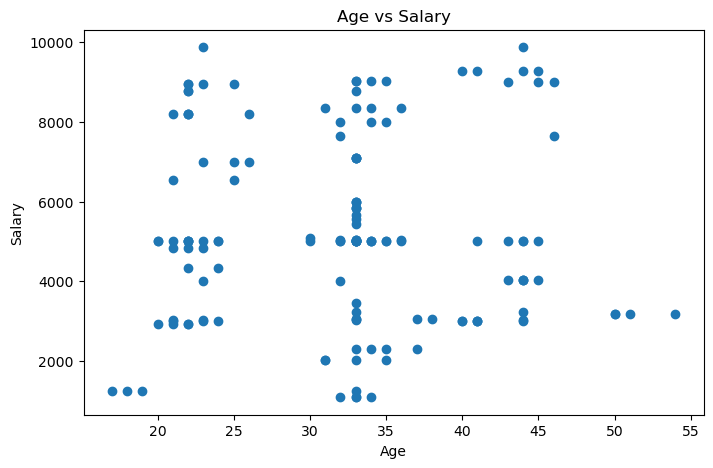

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["age"], df["salary"])

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()

In [ ]:
Number of People from Each Place

In [17]:
place_counts = df["place"].value_counts()

print(place_counts)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


In [ ]:
Visualize

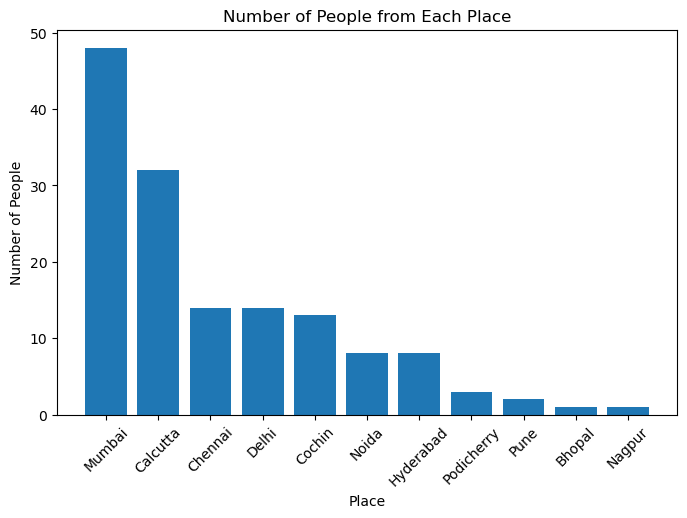

In [18]:
#Visual representation — Bar Chart
import matplotlib.pyplot as plt

place_counts = df["place"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(place_counts.index, place_counts.values)

plt.xlabel("Place")
plt.ylabel("Number of People")
plt.title("Number of People from Each Place")

plt.xticks(rotation=45)

plt.show()

In [ ]:
Data Encoding

In [20]:
import pandas as pd

df_encoded = pd.get_dummies(
    df,
    columns=["company", "place", "country"],
    drop_first=True
)

print(df_encoded.head())

    age  salary  gender  company_Congnizant  company_Infosys  \
0  20.0  5000.0       0               False            False   
1  30.0  5000.0       0               False             True   
2  35.0  2300.0       0               False            False   
3  40.0  3000.0       0               False             True   
4  23.0  4000.0       0               False            False   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                    False         True                              False   
1                    False        False                              False   
2                    False         True                              False   
3                    False        False                              False   
4                    False         True                              False   

   place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  \
0           False           True         False        False       

In [ ]:
Feature Scaling

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_encoded[["age", "salary"]] = scaler.fit_transform(
    df_encoded[["age", "salary"]]
)

print(df_encoded.head())

        age    salary  gender  company_Congnizant  company_Infosys  \
0 -1.484676 -0.100827       0               False            False   
1 -0.267174 -0.100827       0               False             True   
2  0.341577 -1.243735       0               False            False   
3  0.950328 -0.947426       0               False             True   
4 -1.119426 -0.524127       0               False            False   

   company_Infosys Pvt Lmt  company_TCS  company_Tata Consultancy Services  \
0                    False         True                              False   
1                    False        False                              False   
2                    False         True                              False   
3                    False        False                              False   
4                    False         True                              False   

   place_Calcutta  place_Chennai  place_Cochin  place_Delhi  place_Hyderabad  \
0           False           Tr